<a href="https://colab.research.google.com/github/Rabbi1067/Machine-Learning-ML-/blob/main/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline


Read dataset

In [ ]:
df=pd.read_csv("PotatoPrice - PotatoPrice.csv")

In [ ]:
df.head()

,potato_kg,price
0,1,10
1,2,20
2,3,25
3,4,40
4,5,55


Scatter plot

Text(0, 0.5, 'price')

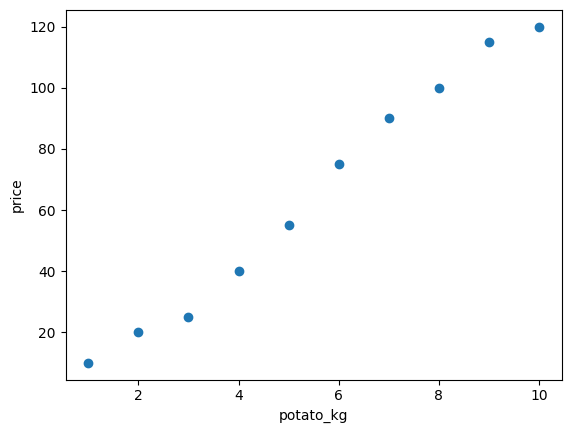

In [ ]:
plt.scatter(df['potato_kg'],df['price'])
plt.xlabel('potato_kg')
plt.ylabel('price')

Correlation

In [ ]:
df.corr()

,potato_kg,price
potato_kg,1.000000,0.993808
price,0.993808,1.000000


Seabon for visualization

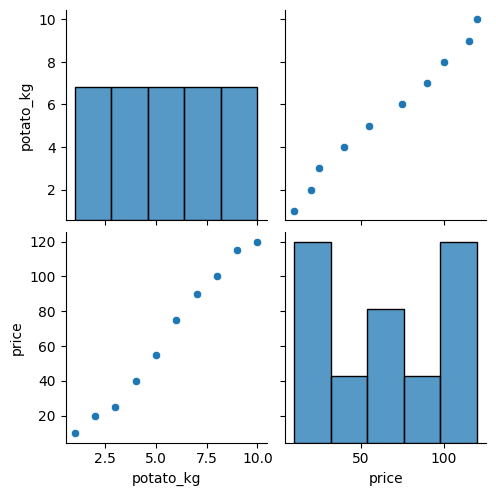

In [ ]:
import seaborn as sns
sns.pairplot(df)

Dependent & Independent feature

In [ ]:
x=df[['potato_kg']] # independent features should ne data frame or 2 dimensional array
y=df['price'] # dependent feature should be array(series or 1D array)


In [ ]:
np.array(x)
#np.array(x).shape


array([[ 1],
       [ 2],
       [ 3],
       [ 4],
       [ 5],
       [ 6],
       [ 7],
       [ 8],
       [ 9],
       [10]])

In [ ]:
np.array(y)
#np.array(y).shape


array([ 10,  20,  25,  40,  55,  75,  90, 100, 115, 120])

Train test split

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
x_train.shape

(8, 1)

Standardization

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit_transform(x_train)

array([[ 0.18569534],
       [-1.67125804],
       [ 0.92847669],
       [-0.92847669],
       [ 1.67125804],
       [-0.18569534],
       [-0.55708601],
       [ 0.55708601]])

In [ ]:
x_test=scaler.transform(x_test)

In [ ]:
x_test

array([[ 1.29986737],
       [-1.29986737]])

Apply Linear regression

In [ ]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()


In [ ]:
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
print("Coefficient or slope: ", model.coef_)
print("Intercept: ", model.intercept_)

Coefficient or slope:  [13.23275862]
Intercept:  -8.405172413793096


Plot Traing data best fit line

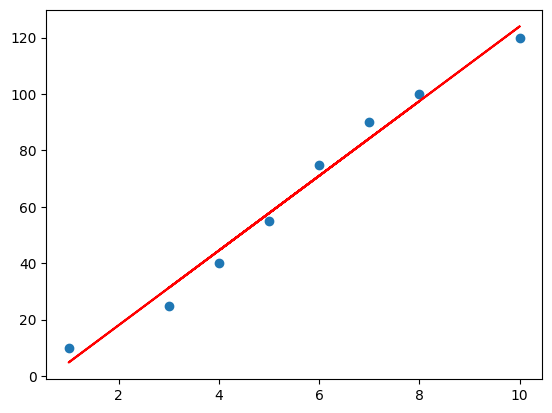

In [ ]:
plt.scatter(x_train,y_train)
plt.plot(x_train,model.predict(x_train),color='red')

Prediction for test data

In [ ]:
model.predict(x_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([  8.7956587 , -25.60600352])

Performance Metrics

In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse=mean_squared_error(y_test,model.predict(x_test))
mae=mean_absolute_error(y_test,model.predict(x_test))
emse=np.sqrt(mse)
print("Mean Squared Error: ",mse)
print("Mean Absolute Error: ",mae)
print("Root Mean Squared Error: ",emse)

Mean Squared Error:  6679.6348346172545
Mean Absolute Error:  75.9051724137931
Root Mean Squared Error:  81.72903299695436


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
from sklearn.metrics import r2_score
score = r2_score(y_test,model.predict(x_test))
print("R2 score: ",score)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


R2 score:  -1.9605029737915811


Adjusted r^2

In [ ]:
#OLS linear regression
import statsmodels.api as sm
x_train_sm=sm.add_constant(x_train)
lr=sm.OLS(y_train,x_train_sm).fit()
lr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.984
Model:                            OLS   Adj. R-squared:                  0.981
Method:                 Least Squares   F-statistic:                     367.7
Date:                Fri, 24 Apr 2026   Prob (F-statistic):           1.30e-06
Time:                        02:31:02   Log-Likelihood:                -23.475
No. Observations:                   8   AIC:                             50.95
Df Residuals:                       6   BIC:                             51.11
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -8.4052      4.226     -1.989      0.094     -18.746       1.935
potato_kg     13.2328      0.690     19.175      0.000      11.544      14.921
==============================================================================
Omnibus:                        3.967   Durbin-Watson:                   1.222
Prob(Omnibus):                  0.138   Jarque-Bera (JB):                0.981
Skew:                          -0.015   Prob(JB):                        0.612
Kurtosis:                       1.285   Cond. No.                         14.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Predicted for new data

In [ ]:
model.predict(scaler.transform([[6]]))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([-5.94791083])